In [ ]:
# ============================================
# Cell 1: Install Required Libraries
# ============================================

# Install required Python libraries
# (Most are pre-installed in Colab, but we ensure consistency)

!pip install pandas faker numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.7 MB/s eta 0:00:00


In [ ]:
# ============================================
# Cell 2: Import Libraries
# ============================================

import pandas as pd          # For data handling
import numpy as np           # For numerical operations
from faker import Faker      # For generating fake data

# Initialize Faker
fake = Faker()

In [ ]:
# ============================================
# Cell 3: Create Sample CSV Files
# ============================================

# Prompt (for Copilot understanding)
# Write Python code in Google Colab to create sample CSV files for HR use cases

num_records = 100

# 1. resumes.csv
resumes = pd.DataFrame({
    "candidate_name": [fake.name() for _ in range(num_records)],
    "skills": np.random.choice(
        ["Python, SQL", "Python, ML", "Excel, Communication", "SQL, Power BI", "Python, SQL, Machine Learning"],
        num_records
    ),
    "experience_years": np.round(np.random.uniform(0, 8, num_records), 1),
    "education": np.random.choice(["B.Tech", "MBA", "MCA", "B.Sc"], num_records)
})
resumes.to_csv("resumes.csv", index=False)


# 2. employee_attrition.csv
attrition = pd.DataFrame({
    "employee_id": [f"EMP{1000+i}" for i in range(num_records)],
    "employee_name": [fake.name() for _ in range(num_records)],
    "attendance_percentage": np.random.randint(50, 100, num_records),
    "performance_score": np.random.randint(1, 5, num_records),
    "overtime_hours": np.random.randint(0, 20, num_records),
    "attrition_risk": np.random.choice(["Low", "Medium", "High"], num_records)
})
attrition.to_csv("employee_attrition.csv", index=False)


# 3. employee_emails.csv
emails = pd.DataFrame({
    "employee_name": [fake.name() for _ in range(num_records)],
    "email": [fake.email() for _ in range(num_records)],
    "role": np.random.choice(["HR", "Manager", "Analyst", "Developer"], num_records)
})
emails.to_csv("employee_emails.csv", index=False)


# 4. performance_data.csv
performance = pd.DataFrame({
    "employee_id": [f"EMP{2000+i}" for i in range(num_records)],
    "employee_name": [fake.name() for _ in range(num_records)],
    "department": np.random.choice(["HR", "IT", "Finance", "Marketing"], num_records),
    "score": np.random.randint(1, 5, num_records),
    "feedback": np.random.choice(
        ["Excellent", "Good", "Needs Improvement", "Outstanding"],
        num_records
    )
})
performance.to_csv("performance_data.csv", index=False)

print("✅ CSV files created successfully!")

✅ CSV files created successfully!


In [ ]:
# ============================================
# Cell 4: Resume Screening Tool
# ============================================

# Prompt:
# Create a Python function to read resumes.csv and filter resumes based on required skills

df = pd.read_csv("resumes.csv")

def filter_resumes(skills_required):
    filtered = df[df['skills'].str.contains('|'.join(skills_required), case=False)]
    return filtered

shortlisted = filter_resumes(["Python", "SQL", "Machine Learning"])

print("✅ Shortlisted Candidates:")
print(shortlisted.head())

✅ Shortlisted Candidates:
     candidate_name                         skills  experience_years education
0     Ryan Schaefer                  SQL, Power BI               4.0    B.Tech
2     Jason Raymond                     Python, ML               2.2      B.Sc
3       Kelly Smith                     Python, ML               5.3       MBA
6       Luis Ramsey                     Python, ML               6.7      B.Sc
7  Matthew Phillips  Python, SQL, Machine Learning               2.9       MBA


In [ ]:
# ============================================
# Cell 5: Attrition Analysis
# ============================================

# Prompt:
# Identify employees with high attrition risk

df_attr = pd.read_csv("employee_attrition.csv")

# Rule-based filtering
high_risk = df_attr[
    (df_attr["attendance_percentage"] < 70) &
    (df_attr["performance_score"] <= 2)
]

print("⚠️ High Attrition Risk Employees:")
print(high_risk.head())

⚠️ High Attrition Risk Employees:
   employee_id    employee_name  attendance_percentage  performance_score  \
0      EMP1000  Jennifer Bishop                     61                  1   
3      EMP1003    Anthony Davis                     53                  1   
8      EMP1008  Kimberly Parker                     52                  2   
13     EMP1013     Bobby Newman                     56                  2   
14     EMP1014        Jason Fry                     55                  2   

    overtime_hours attrition_risk  
0                1            Low  
3                7           High  
8                2            Low  
13              15            Low  
14              14            Low  


In [ ]:
# ============================================
# Cell 6: HR Dashboard Summary
# ============================================

# Prompt:
# Prepare summary statistics

df_attr = pd.read_csv("employee_attrition.csv")

summary = {
    "Average Attendance": df_attr["attendance_percentage"].mean(),
    "Average Performance": df_attr["performance_score"].mean(),
    "Attrition Count": df_attr[df_attr["attrition_risk"] == "High"].shape[0]
}

dept_count = df_attr["attrition_risk"].value_counts()

print("📊 Summary Stats:")
print(summary)

print("\n📌 Attrition Risk Distribution:")
print(dept_count)

📊 Summary Stats:
{'Average Attendance': np.float64(74.48), 'Average Performance': np.float64(2.55), 'Attrition Count': 25}

📌 Attrition Risk Distribution:
attrition_risk
Low       40
Medium    35
High      25
Name: count, dtype: int64


In [ ]:
# ============================================
# Cell 7: Email Generator
# ============================================

# Prompt:
# Generate personalized emails

df_email = pd.read_csv("employee_emails.csv")

def generate_email(row):
    return f"""
    Dear {row['employee_name']},

    We are pleased to have you as a {row['role']} in our organization.
    We appreciate your contribution and look forward to your continued success.

    Regards,
    HR Team
    """

df_email["Generated_Email"] = df_email.apply(generate_email, axis=1)

print("📧 Sample Emails:")
print(df_email[["employee_name", "Generated_Email"]].head())

📧 Sample Emails:
      employee_name                                    Generated_Email
0     Ashley Bowers  \n    Dear Ashley Bowers,\n\n    We are please...
1      Erin Burgess  \n    Dear Erin Burgess,\n\n    We are pleased...
2    Kathleen Davis  \n    Dear Kathleen Davis,\n\n    We are pleas...
3  Anthony Davidson  \n    Dear Anthony Davidson,\n\n    We are ple...
4     Frank Barajas  \n    Dear Frank Barajas,\n\n    We are please...


In [ ]:
# ============================================
# Cell 8: Performance Report Generator
# ============================================

# Prompt:
# Generate performance report

df_perf = pd.read_csv("performance_data.csv")

def performance_label(score):
    if score >= 4:
        return "High Performer"
    elif score >= 2:
        return "Average Performer"
    else:
        return "Needs Improvement"

df_perf["Performance_Level"] = df_perf["score"].apply(performance_label)

print("📈 Performance Report:")
print(df_perf.head())

📈 Performance Report:
  employee_id      employee_name department  score           feedback  \
0     EMP2000      Brooke Warner  Marketing      1          Excellent   
1     EMP2001    Caitlin Jenkins  Marketing      2        Outstanding   
2     EMP2002       Vanessa Bell    Finance      3  Needs Improvement   
3     EMP2003         Amy Duncan  Marketing      4          Excellent   
4     EMP2004  Dr. Donna Barrera         IT      4  Needs Improvement   

   Performance_Level  
0  Needs Improvement  
1  Average Performer  
2  Average Performer  
3     High Performer  
4     High Performer  


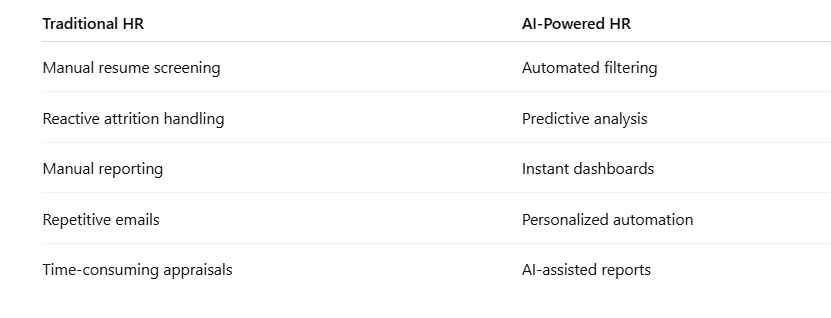